In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing cleaned_data file for cleaning the data properly

df = pd.read_csv("cleaned_data.csv")

In [3]:
# renaming the column name

df2 = df.rename(columns={'Book name':'Book_name'})

In [4]:
# making the emoji rating stars into strings then moving it into a variable

one = '⭐'
two = '⭐⭐'
three = '⭐⭐⭐'
four = '⭐⭐⭐⭐'
five = '⭐⭐⭐⭐⭐'

# converting the ratings from text to actual rating signs

rating_map = {
    'One':one,
    'Two':two,
    'Three':three,
    'Four':four,
    'Five':five
}

df2['Rating']=df2['Rating'].replace(rating_map)
df2 

,Unnamed: 0,book_name,Price,Rating
0,0,A Light in the Attic,51.77,⭐⭐⭐
1,1,Tipping the Velvet,53.74,⭐
2,2,Soumission,50.10,⭐
3,3,Sharp Objects,47.82,⭐⭐⭐⭐
4,4,Sapiens: A Brief History of Humankind,54.23,⭐⭐⭐⭐⭐
...,...,...,...,...
995,995,Poses for Artists Volume 1 - Dynamic and Sitti...,41.06,⭐
996,996,Poems That Make Grown Women Cry,14.19,⭐⭐⭐⭐
997,997,"Nightingale, Sing",38.28,⭐
998,998,Night Sky with Exit Wounds,41.05,⭐


## Data analysis & visulization

In [6]:
highest_price = df2['Price'].max()
highest_price

59.99

In [7]:
lowest_price = df2['Price'].min()
lowest_price

10.0

## Feature Engineering⬇️

### Creating a new Column called "Price_with_Rating", this column contains 6 important features of books :-
###### 1.Book with High price + High rating
###### 2.Book with High price + Low rating
###### 3.Book with Medium price + High rating
###### 3.Book with Medium price + Low rating
###### 5.Book with Low price + High rating
###### 6.Book with Low price + Low rating

In [8]:
a = '⭐'
b = '⭐⭐'
c = '⭐⭐⭐'
d = '⭐⭐⭐⭐'
e = '⭐⭐⭐⭐⭐'

In [14]:
def categorize(row):
    if row['Price'] >= 40:
        Price = 'High price'
    elif row['Price'] >= 20:
        Price = 'Medium price'
    else:
        Price = 'Low price'

    if row['Rating'] >= d:
        Rating = 'High rating'
    else:
        Rating = 'Low rating'

    return f"{Price} + {Rating}"  

df2['Price_with_Rating'] = df2.apply(categorize, axis=1)    

In [15]:
df2

,Unnamed: 0,book_name,Price,Rating,Price_with_Rating,Rating_in_number
0,0,A Light in the Attic,51.77,⭐⭐⭐,High price + Low rating,3
1,1,Tipping the Velvet,53.74,⭐,High price + Low rating,1
2,2,Soumission,50.10,⭐,High price + Low rating,1
3,3,Sharp Objects,47.82,⭐⭐⭐⭐,High price + High rating,4
4,4,Sapiens: A Brief History of Humankind,54.23,⭐⭐⭐⭐⭐,High price + High rating,5
...,...,...,...,...,...,...
995,995,Poses for Artists Volume 1 - Dynamic and Sitti...,41.06,⭐,High price + Low rating,1
996,996,Poems That Make Grown Women Cry,14.19,⭐⭐⭐⭐,Low price + High rating,4
997,997,"Nightingale, Sing",38.28,⭐,Medium price + Low rating,1
998,998,Night Sky with Exit Wounds,41.05,⭐,High price + Low rating,1


In [16]:
# Converting star emojis Ratings into number ratings 

def num_rating(row):
    if row['Rating'] == '⭐':
        Rating = '1'
    elif row['Rating'] == '⭐⭐':
        Rating = '2'
    elif row['Rating'] == '⭐⭐⭐':
        Rating = '3'
    elif row['Rating'] == '⭐⭐⭐⭐': 
        Rating = '4'
    else:
        Rating = '5'
    return f"{Rating}"

df2['Rating_in_number'] = df2.apply(num_rating, axis=1) 

In [17]:
df2

,Unnamed: 0,book_name,Price,Rating,Price_with_Rating,Rating_in_number
0,0,A Light in the Attic,51.77,⭐⭐⭐,High price + Low rating,3
1,1,Tipping the Velvet,53.74,⭐,High price + Low rating,1
2,2,Soumission,50.10,⭐,High price + Low rating,1
3,3,Sharp Objects,47.82,⭐⭐⭐⭐,High price + High rating,4
4,4,Sapiens: A Brief History of Humankind,54.23,⭐⭐⭐⭐⭐,High price + High rating,5
...,...,...,...,...,...,...
995,995,Poses for Artists Volume 1 - Dynamic and Sitti...,41.06,⭐,High price + Low rating,1
996,996,Poems That Make Grown Women Cry,14.19,⭐⭐⭐⭐,Low price + High rating,4
997,997,"Nightingale, Sing",38.28,⭐,Medium price + Low rating,1
998,998,Night Sky with Exit Wounds,41.05,⭐,High price + Low rating,1


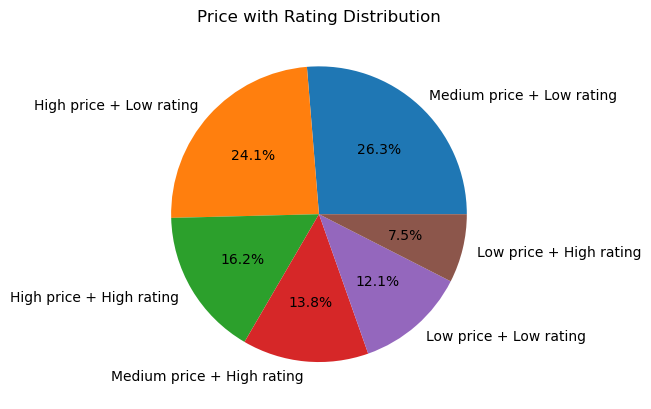

In [18]:
# Visualizing Data in Pie chart

# Count categories
counts = df2['Price_with_Rating'].value_counts()

# Plot
plt.figure()
plt.pie(
    counts.values, 
    labels=counts.index, 
    autopct='%1.1f%%'
)

plt.title('Price with Rating Distribution')
plt.show()

In [22]:
df2.to_csv("data_for_model.csv",index=False)

## Download link of "data_for_model.csv"
http://localhost:8888/files/data_for_model.csv?_xsrf=2%7C72cbb69c%7C43c3a14dad9401b7a42862f06b608af7%7C1772431389